In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"




In [2]:
models = ['AME2020', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1', 'UNEDF2', 'FRDM12', 'HFB24', 'BCPM', 'D1M'] #Here I am copying all the models that we will be using 

#In the line below we are going to access the data that we have for the binding energies of different models
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"]}

In [3]:
models_selected=['AME2020','ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1', 'UNEDF2', 'FRDM12', 'HFB24', 'BCPM', 'D1M'] 
# Now we want to create an array that contains the N and Z values of the true data.
filtered_NZ = np.array([models_data_sets['AME2020']['N'].tolist(), models_data_sets['AME2020']['Z'].tolist()]).T
filtered_NZ_new = []
for isotope in filtered_NZ:
    if (isotope[0] >= 8) & (isotope[1] >= 8) & (isotope[0]%2 == 0) & (isotope[1]%2 == 0):
        filtered_NZ_new.append(isotope.tolist())


In [4]:
for model in models_selected:
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
            filtered_NZ_new.append(isotope)
    filtered_NZ = np.array(filtered_NZ_new)

In [5]:
filtered_NZ.shape

(629, 2)

In [6]:
filtered_NZ_df = pd.DataFrame(filtered_NZ)
filtered_NZ_df.columns = ['N', 'Z']
filtered_NZ_df

,N,Z
0,8,8
1,10,8
2,12,8
3,14,8
4,16,8
...,...,...
624,154,106
625,156,106
626,156,108
627,158,108


In [7]:
# Let's now make a data frame that contains all the predictions of different models
for model in models_selected:
    a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'left', on = ['N', 'Z'])
    filtered_NZ_df[model] = a['BE']

In [8]:
filtered_NZ_df

,N,Z,AME2020,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,UNEDF2,FRDM12,HFB24,BCPM,D1M
0,8,8,127.619315,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460,121.950687,128.03,125.632422,127.007944,128.028806
1,10,8,139.807766,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181,136.259511,141.84,138.095058,141.145503,141.000517
2,12,8,151.371414,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242,148.128389,152.98,151.927694,153.041593,151.904718
3,14,8,162.027188,160.513,161.884,163.303,163.311,170.486446,167.278899,166.483309,163.855872,164.192707,157.219361,158.409799,161.39,161.930329,163.391272,160.883175
4,16,8,168.952452,167.472,168.465,170.768,170.970,178.908577,174.420231,173.303716,170.930478,171.196394,163.998623,165.167568,165.98,168.322965,170.887643,166.974152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,1909.066432,1910.765,1907.813,1909.928,1914.193,1894.445901,1900.875946,1898.639172,1902.293050,1907.479821,1908.851310,1908.842630,1909.73,1909.145350,1905.125660,1901.308909
625,156,106,1923.387483,1925.019,1921.738,1924.361,1928.042,1909.221132,1915.371887,1912.434046,1916.575965,1921.884406,1922.815073,1922.920406,1923.99,1923.647986,1919.402948,1915.781516
626,156,108,1926.771317,1928.415,1925.436,1927.488,1932.395,1911.680941,1918.341803,1916.133844,1919.723353,1925.454882,1926.206982,1926.326995,1927.52,1926.745956,1922.608355,1918.524169
627,158,108,1941.337453,1943.010,1939.691,1942.276,1946.498,1927.231556,1933.157370,1930.669126,1934.554087,1940.259078,1940.812152,1940.991163,1942.52,1941.618592,1937.508145,1933.626547


In [9]:
stable_isotopes = np.loadtxt('Stable-Isotopes.txt')


In [10]:
stable_coordinates = []
for isotope in stable_isotopes:
    if (isotope[0] >= 8) & (isotope[1] >= 8) & (isotope[0]%2 == 0) & (isotope[1]%2 == 0):
        stable_coordinates.append(isotope)
stable_coordinates = np.array(stable_coordinates)

In [11]:
stable_coordinates

array([[  8.,   8.],
       [ 10.,   8.],
       [ 10.,  10.],
       [ 12.,  10.],
       [ 12.,  12.],
       [ 14.,  12.],
       [ 14.,  14.],
       [ 16.,  14.],
       [ 16.,  16.],
       [ 18.,  16.],
       [ 20.,  16.],
       [ 18.,  18.],
       [ 20.,  18.],
       [ 22.,  18.],
       [ 20.,  20.],
       [ 22.,  20.],
       [ 24.,  20.],
       [ 26.,  20.],
       [ 28.,  20.],
       [ 24.,  22.],
       [ 26.,  22.],
       [ 28.,  22.],
       [ 26.,  24.],
       [ 28.,  24.],
       [ 30.,  24.],
       [ 28.,  26.],
       [ 30.,  26.],
       [ 32.,  26.],
       [ 30.,  28.],
       [ 32.,  28.],
       [ 34.,  28.],
       [ 36.,  28.],
       [ 34.,  30.],
       [ 36.,  30.],
       [ 38.,  30.],
       [ 40.,  30.],
       [ 38.,  32.],
       [ 40.,  32.],
       [ 42.,  32.],
       [ 44.,  32.],
       [ 40.,  34.],
       [ 42.,  34.],
       [ 44.,  34.],
       [ 46.,  34.],
       [ 48.,  34.],
       [ 42.,  36.],
       [ 44.,  36.],
       [ 46.,

In [12]:
## Here are some functions that will be useful for our analysis

In [13]:
#Some functions for plotting capabilities

def plot_bars(values, labels, title="Bar Plot", color='blue'):
    """
    Create a bar plot based on the provided values and labels.

    Parameters:
    - values (list): A list of numerical values for the bars.
    - labels (list): A list of labels for each bar.
    - title (str): The title for the bar plot. Default is "Bar Plot".
    - color (str): Color for the bars. Default is 'blue'.
    """
    
    if len(values) != len(labels):
        raise ValueError("Length of values and labels should be the same.") #This is just a command that prints out the problem if these 2 values
        #are not the same
    
    plt.figure(figsize=(10, 5))
    plt.bar(labels, values, color=color)
    plt.title(title)
    plt.xlabel('Models')
    plt.ylabel('Vt Coordinates')
    plt.xticks(labels,fontsize=10,rotation='vertical')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


def Plotter2D_single(data):
    xvals,yvals,zvals = data
    #A plotter to see principal components in 2D
    plt.rc("xtick", labelsize=25)
    plt.rc("ytick", labelsize=25)
    
    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Z-Value', fontsize=25) 
    cbar.ax.tick_params(labelsize=20) 
    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    ax.grid(True)
    # ax.axis('equal')

    plt.show()

def Plotter3D_single(data,elev=30,azim=-60):
    xvals,yvals,zvals = data
    #A plotter to see principal components in 3D
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)

    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = (zvals - z_min) / (z_max - z_min)

    # Create figure for 3D plot
    fig = plt.figure(figsize=(8, 6), dpi=200)
    ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma(z_normalized))

    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Scaled Z')


    plt.show()    



def Plotter2D(ax,xvals,yvals,zvals):
    #A plotter to see principal components in 2D, part of the big plotter



    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Z-Value', fontsize=25) 
    cbar.ax.tick_params(labelsize=20) 




    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    ax.grid(True)
    ax.axis('equal')

    # plt.show()

def Plotter3D(ax,xvals,yvals,zvals,elev=30,azim=-60):
    #A plotter to see principal components in 3D, part of the big plotter


    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = (zvals - z_min) / (z_max - z_min)

    # Create figure for 3D plot
    # fig = plt.figure(figsize=(8, 6), dpi=200)
    # ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma(z_normalized))

    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Scaled Z')


    # plt.show()    



def PlotMultiple(data_sets,angles_sheet=None):
    # Determine the number of rows needed for the plots
    n_rows = len(data_sets)
    # Each data_sets element should look like [x,y,z]

    # Create a figure with subplots
    fig = plt.figure(figsize=(20, 8 * n_rows), dpi=200)

    for i, (xvals, yvals, zvals) in enumerate(data_sets):
        # 2D plot
        ax_2d = fig.add_subplot(n_rows, 2, 2 * i + 1)
        Plotter2D(ax_2d, xvals, yvals, zvals)

        # 3D plot
        ax_3d = fig.add_subplot(n_rows, 2, 2 * i + 2, projection='3d')
        if angles_sheet == None:
            Plotter3D(ax_3d, xvals, yvals, zvals)
        else:
            Plotter3D(ax_3d, xvals, yvals, zvals,elev=angles_sheet[0],azim=angles_sheet[1])

    plt.tight_layout()
    plt.show()



In [14]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)


In [15]:
def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)


In [16]:
def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [17]:
Full_set = np.copy(filtered_NZ)
distance1 = 2
distance2 = 3

train_set, validation_set, test_set, train_coordinates, validation_coordinates, test_coordinates = separate_points_distance_allSets(Full_set, stable_coordinates, distance1, distance2)

In [18]:
models_output = filtered_NZ_df
models_output['A'] = models_output['N'] + models_output['Z']
cols = models_output.columns.tolist()

In [19]:
cols

['N',
 'Z',
 'AME2020',
 'ME2',
 'MEdelta',
 'PC1',
 'NL3S',
 'SKMS',
 'SKP',
 'SLY4',
 'SV',
 'UNEDF0',
 'UNEDF1',
 'UNEDF2',
 'FRDM12',
 'HFB24',
 'BCPM',
 'D1M',
 'A']

In [20]:
cols[2] , cols[-1] = cols[-1], cols[2]

In [21]:
models_output = models_output[cols]

In [22]:
models_output

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,UNEDF2,FRDM12,HFB24,BCPM,D1M,AME2020
0,8,8,16,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460,121.950687,128.03,125.632422,127.007944,128.028806,127.619315
1,10,8,18,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181,136.259511,141.84,138.095058,141.145503,141.000517,139.807766
2,12,8,20,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242,148.128389,152.98,151.927694,153.041593,151.904718,151.371414
3,14,8,22,160.513,161.884,163.303,163.311,170.486446,167.278899,166.483309,163.855872,164.192707,157.219361,158.409799,161.39,161.930329,163.391272,160.883175,162.027188
4,16,8,24,167.472,168.465,170.768,170.970,178.908577,174.420231,173.303716,170.930478,171.196394,163.998623,165.167568,165.98,168.322965,170.887643,166.974152,168.952452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,260,1910.765,1907.813,1909.928,1914.193,1894.445901,1900.875946,1898.639172,1902.293050,1907.479821,1908.851310,1908.842630,1909.73,1909.145350,1905.125660,1901.308909,1909.066432
625,156,106,262,1925.019,1921.738,1924.361,1928.042,1909.221132,1915.371887,1912.434046,1916.575965,1921.884406,1922.815073,1922.920406,1923.99,1923.647986,1919.402948,1915.781516,1923.387483
626,156,108,264,1928.415,1925.436,1927.488,1932.395,1911.680941,1918.341803,1916.133844,1919.723353,1925.454882,1926.206982,1926.326995,1927.52,1926.745956,1922.608355,1918.524169,1926.771317
627,158,108,266,1943.010,1939.691,1942.276,1946.498,1927.231556,1933.157370,1930.669126,1934.554087,1940.259078,1940.812152,1940.991163,1942.52,1941.618592,1937.508145,1933.626547,1941.337453


In [23]:
models_output_train = models_output.iloc[train_coordinates]
models_output_validation = models_output.iloc[validation_coordinates]
models_output_test = models_output.iloc[test_coordinates]

In [24]:
models_output_train

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,UNEDF2,FRDM12,HFB24,BCPM,D1M,AME2020
0,8,8,16,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460,121.950687,128.03,125.632422,127.007944,128.028806,127.619315
1,10,8,18,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181,136.259511,141.84,138.095058,141.145503,141.000517,139.807766
2,12,8,20,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242,148.128389,152.98,151.927694,153.041593,151.904718,151.371414
6,8,10,18,132.232,133.928,133.508,134.073,137.483993,137.168743,137.486724,134.683069,135.653893,129.334404,129.514847,134.37,130.140392,133.809916,133.658054,132.142639
7,10,10,20,155.363,157.957,156.384,155.807,159.622620,159.549214,159.630263,157.258948,158.396315,152.933568,153.024112,160.81,162.743027,155.874820,155.896923,160.644824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,144,92,236,1788.373,1787.242,1789.981,1789.477,1782.370394,1784.809263,1779.815688,1785.220250,1789.492291,1789.219699,1789.245900,1790.23,1789.856383,1787.404888,1784.473139,1790.410554
584,146,92,238,1799.157,1798.298,1801.261,1800.272,1794.303879,1796.041869,1790.367089,1796.415919,1800.731144,1800.185345,1800.308703,1801.64,1801.189019,1798.686794,1795.798446,1801.690036
585,148,92,240,1809.698,1809.045,1812.210,1810.588,1805.506661,1806.578583,1800.227689,1806.935502,1811.256842,1810.521068,1810.741574,1812.62,1812.051655,1809.512689,1806.613247,1812.424920
590,142,94,236,1788.073,1785.551,1788.675,1789.604,1777.712919,1782.151419,1778.454041,1782.876942,1787.400419,1787.868161,1787.815069,1788.18,1787.901717,1785.328901,1782.014156,1788.388931


In [25]:
color_trainig=colors_sets[9]
color_validation='orange'
color_testing=colors_sets[3]

marker_trainig='s'
marker_validation='*'
marker_testing='o'



size_trainig=30
size_validation=80
size_testing=35

alpha_trainig=0.8
alpha_validation=0.9
alpha_testing=0.4

In [26]:
model_predictions = models_output.iloc[:,3:-1].values
model_predictions_train = models_output_train.iloc[:,3:-1].values
model_predictions_validation = models_output_validation.iloc[:,3:-1].values
model_predictions_test = models_output_test.iloc[:,3:-1].values

predictions_mean = np.mean(model_predictions, axis = 1)
predictions_mean_train = np.mean(model_predictions_train, axis = 1)
predictions_mean_validation = np.mean(model_predictions_validation, axis = 1)
predictions_mean_test = np.mean(model_predictions_test, axis = 1)

model_predictions_centered = model_predictions - predictions_mean[:,None]
model_predictions_centered_train  = model_predictions_train - predictions_mean_train.reshape((300,1))
model_predictions_centered_validation = model_predictions_validation - predictions_mean_validation[:,np.newaxis]
model_predictions_centered_test = model_predictions_test - predictions_mean_test[:,None]

In [27]:
# model_predictions_centered.shape

## Let's now try to incoporate the weights at different inputs (or region dominated analysis)

In [28]:
lower_selected_Z = 50
upper_selected_Z = 50
Z_range=(lower_selected_Z,upper_selected_Z)
N_range=(0,300)


filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                     (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  

filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                     (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]

filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                     (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]

filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                     (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]


stable_selected_isotope=[]

for i in range(len(stable_coordinates)):
    if (stable_coordinates[i][1] >= lower_selected_Z) & (stable_coordinates[i][1] <= upper_selected_Z):
        stable_selected_isotope.append(stable_coordinates[i])

stable_selected_isotope=np.array(stable_selected_isotope)

# df[df['Column1'].isin(values_array)]

filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                     (models_output_train['N'].isin(stable_selected_isotope.T[0]))]

In [29]:
filtered_models_output

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,UNEDF2,FRDM12,HFB24,BCPM,D1M,AME2020
240,50,50,100,825.941,822.052,826.926,828.530,826.288242,822.691386,828.611583,824.726244,826.912170,828.830587,829.853181,825.52,824.885137,823.496576,822.968432,825.162600
241,52,50,102,848.659,846.196,849.814,851.207,849.364428,847.781508,851.605589,848.943443,851.417385,852.516320,853.344606,850.23,849.067773,846.791661,845.646524,849.091993
242,54,50,104,870.666,869.126,871.759,873.135,871.383529,871.023119,873.167295,871.236657,874.244098,874.546832,875.381538,872.84,872.200409,869.065886,867.415059,871.926786
243,56,50,106,891.969,891.217,893.213,894.343,892.190570,892.942648,893.767401,892.399488,895.584326,895.511521,896.210348,894.41,893.713045,890.480655,888.405181,893.796060
244,58,50,108,912.716,912.408,914.077,914.826,911.582569,913.579282,913.499580,912.620544,915.727306,915.682848,915.839110,914.78,914.315681,911.281193,908.688814,914.654948
245,60,50,110,932.674,932.575,934.246,934.568,930.135328,933.197027,932.670884,932.051589,935.014543,934.973849,934.785166,934.59,934.058316,931.323345,928.295250,934.569625
246,62,50,112,952.012,951.805,953.690,953.532,948.361300,952.039737,951.230248,950.784548,953.622055,953.510473,953.085434,953.49,953.000952,950.673809,947.226378,953.525317
247,64,50,114,970.364,970.102,972.308,971.678,966.282253,970.160814,969.054331,968.793607,971.551835,971.249964,970.970799,971.47,971.073588,969.321409,965.470068,971.572649
248,66,50,116,988.071,987.348,990.025,988.990,983.758860,987.617816,986.193294,986.150392,988.821770,988.311787,988.017985,988.60,988.436224,987.002771,983.022213,988.681526
249,68,50,118,1004.653,1003.724,1006.883,1005.503,1000.771672,1004.358485,1002.927549,1002.858717,1005.495934,1004.626641,1004.059960,1004.84,1005.008860,1004.373072,999.910286,1004.951024


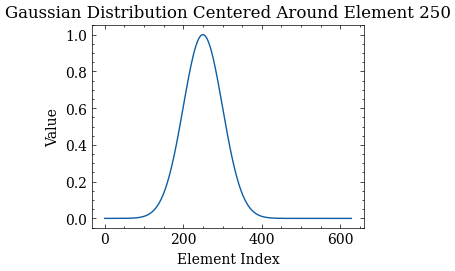

In [30]:
n =  629
# Center of the Gaussian distribution (index)
center_index = 250
plt.rcParams['text.usetex'] = False
# Standard deviation (spread) of the distribution
std_dev = 50  # You can adjust this value

# Generate an array of indices
indices = np.arange(n)

# Calculate the Gaussian distribution
gaussian_distribution = np.exp(-0.5 * ((indices - center_index) / std_dev) ** 2)

# Normalize the distribution to have a peak value of 1 (optional)
gaussian_distribution /= np.max(gaussian_distribution)

# Plotting the distribution
plt.plot(indices, gaussian_distribution)
plt.title(f'Gaussian Distribution Centered Around Element {center_index}')
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.show()

# Print the first 10 elements of the list as a sample
# print(gaussian_distribution[:10])

In [31]:
# We will now make a diagonal matrix of square root of weight to multiply it into our centered matrix (the square root will accounts for
# maximum covariance matrix)
weight_list = gaussian_distribution
weight_list_train = weight_list[train_coordinates]
weight_list_validation = weight_list[validation_coordinates]
weight_list_test = weight_list[test_coordinates]

weight_matrix = np.diag(gaussian_distribution)
weight_matrix_train = np.diag(weight_list_train)
weight_matrix_validation = np.diag(weight_list_validation)
weight_matrix_test = np.diag(weight_list_test)

In [78]:
weighted_model_predictions = np.sqrt(weight_matrix).dot(model_predictions)
weighted_model_predictions_train = weighted_model_predictions[train_coordinates]
weighted_model_predictions_validation = weighted_model_predictions[validation_coordinates]
weighted_model_predictions_test = weighted_model_predictions[test_coordinates]

weighted_predictions_mean = np.mean(weighted_model_predictions, axis = 1)
weighted_predictions_mean_train = np.mean(weighted_model_predictions_train, axis = 1)
weighted_predictions_mean_validation = np.mean(weighted_model_predictions_validation, axis = 1)
weighted_predictions_mean_test = np.mean(weighted_model_predictions_test, axis = 1)

weighted_model_predictions_centered = weighted_model_predictions - weighted_predictions_mean[:,None]
weighted_model_predictions_centered_train  = weighted_model_predictions_train - weighted_predictions_mean_train.reshape((300,1))
weighted_model_predictions_centered_validation = weighted_model_predictions_validation - weighted_predictions_mean_validation[:,np.newaxis]
weighted_model_predictions_centered_test = weighted_model_predictions_test - weighted_predictions_mean_test[:,None]

In [79]:
# Now we perfrom SVD to our new matrix
weighted_U, weighted_S, weighted_Vt = np.linalg.svd(weighted_model_predictions_centered_train)

In [80]:
weighted_U.shape

(300, 300)

In [81]:
weighted_Vt.shape

(15, 15)

### Let's see how the singular value decays

[4.91811740e+01 2.11064895e+01 1.87780616e+01 1.03019318e+01
 8.72502685e+00 6.58793982e+00 4.02313330e+00 3.85737658e+00
 2.70962550e+00 2.46775162e+00 1.67075623e+00 1.51316321e+00
 1.35119061e+00 7.75497546e-01 3.63246417e-12]


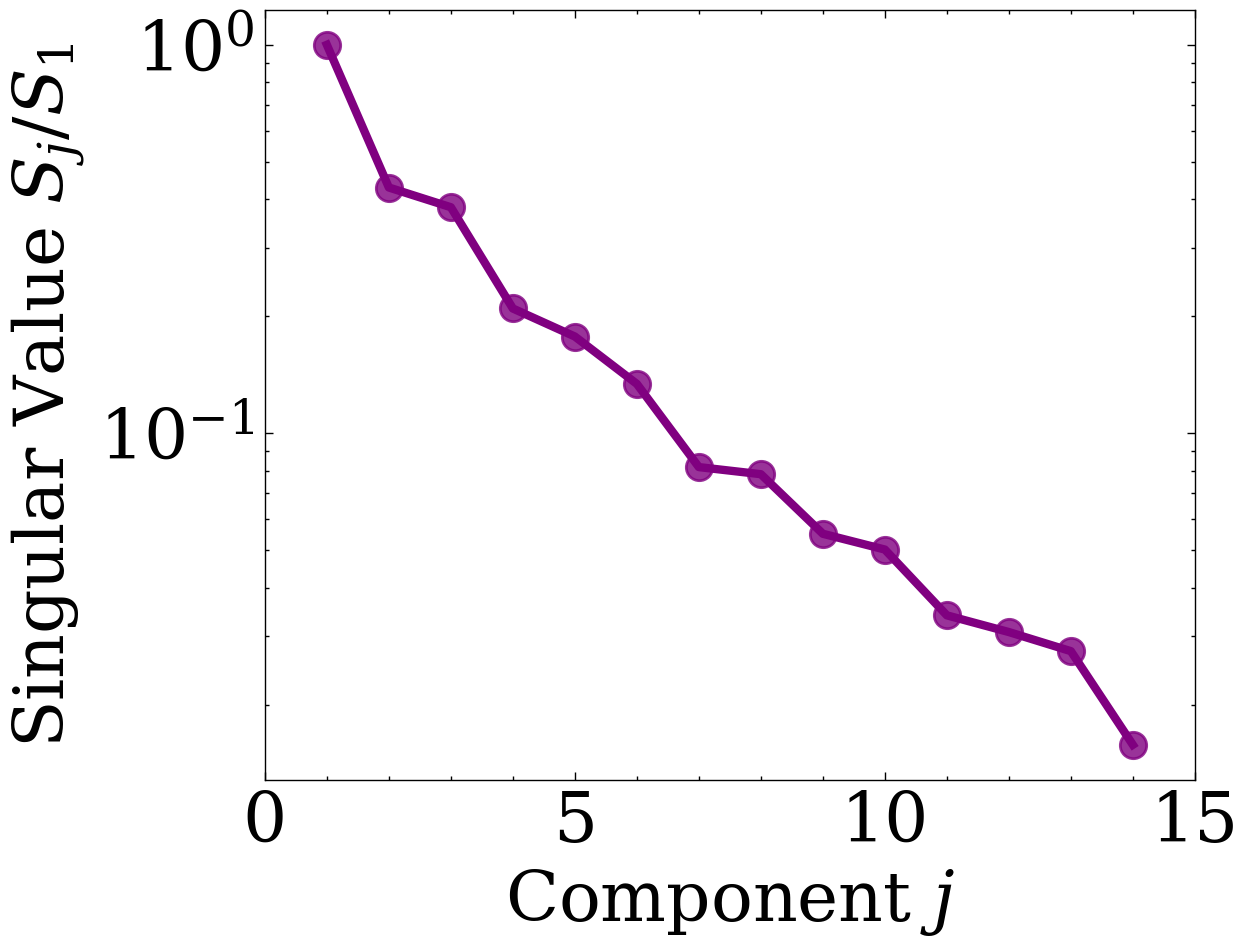

In [82]:
print(weighted_S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, weighted_S.size ), weighted_S[:-1]/weighted_S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, weighted_S.size ), weighted_S[:-1]/weighted_S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,5,10,15])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.show()

### Now let's proceed by performing our usual analysis

In [83]:
components_kept = 7

In [84]:
weighted_S_hat = weighted_S[:components_kept]
# For some reasons I do not fully understand, we will consider the case that Vt_hat with no scaling at all to be
weighted_Vt_hat = np.array([weighted_Vt[i]/weighted_S[i] for i in range(components_kept)]) #Vt[i] will give you the (i+1)th row of our matrix
weighted_U_hat = weighted_U[:,:components_kept]

#The S needs to be absorved somewhere, either on the U or the V. We chosed the V, but we might want to have normalized Vs for plotting:
weighted_Vt_hat_normalized = weighted_Vt[:components_kept,:]
weighted_Vt_hat_normalized.shape

(7, 15)

In [85]:
#Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong


weighted_models_PC_train = {}

weighted_models_PC_train["PC_0"] = weighted_predictions_mean_train

for i in range(components_kept):
    weighted_models_PC_train["PC_" + str(i+1)] = np.dot(weighted_Vt_hat[i], weighted_model_predictions_train.T)

weighted_models_PC_train["N"] = models_output_train["N"]
weighted_models_PC_train["Z"] = models_output_train["Z"]
weighted_models_PC_train["A"] = models_output_train["N"] + models_output_train["Z"]

weighted_models_PC_train = pd.DataFrame(weighted_models_PC_train)

In [86]:
weighted_models_PC_train

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,N,Z,A
0,0.245215,0.000166,0.000033,3.775971e-04,-0.000440,-1.552396e-04,0.001105,-1.056144e-03,8,8,16
1,0.286489,0.000188,-0.000240,4.930659e-04,-0.000299,-3.862207e-04,0.001343,-1.612904e-03,10,8,18
2,0.326425,0.000191,-0.000449,6.808665e-04,-0.000389,-3.766303e-04,0.001144,-1.514757e-03,12,8,20
6,0.347416,0.000239,-0.000433,5.499274e-04,-0.000290,-6.594393e-04,0.001519,-2.101777e-03,8,10,18
7,0.429127,0.000046,-0.000534,4.957218e-04,-0.001455,4.414512e-04,0.000026,1.170901e-04,10,10,20
...,...,...,...,...,...,...,...,...,...,...,...
583,0.027309,-0.000003,0.000004,2.825911e-07,-0.000004,1.220655e-06,-0.000010,3.383230e-06,144,92,236
584,0.025707,-0.000002,0.000003,8.714384e-07,-0.000004,1.885644e-06,-0.000010,4.070814e-06,146,92,238
585,0.024185,-0.000002,0.000003,1.454879e-06,-0.000004,2.621432e-06,-0.000010,4.824231e-06,148,92,240
590,0.017032,-0.000002,0.000003,-7.208785e-07,-0.000003,-7.691433e-07,-0.000005,5.769735e-07,142,94,236


In [87]:
weighted_models_PC_validation = {}

weighted_models_PC_validation["PC_0"] = weighted_predictions_mean_validation

for i in range(components_kept):
    weighted_models_PC_validation["PC_" + str(i+1)] = np.dot(weighted_Vt_hat[i], weighted_model_predictions_validation.T)

weighted_models_PC_validation["N"] = models_output_validation["N"]
weighted_models_PC_validation["Z"] = models_output_validation["Z"]
weighted_models_PC_validation["A"] = models_output_validation["N"] + models_output_validation["Z"]

weighted_models_PC_validation = pd.DataFrame(weighted_models_PC_validation)

In [88]:
weighted_models_PC_test = {}

weighted_models_PC_test["PC_0"] = weighted_predictions_mean_test

for i in range(components_kept):
    weighted_models_PC_test["PC_" + str(i+1)] = np.dot(weighted_Vt_hat[i], weighted_model_predictions_test.T)

weighted_models_PC_test["N"] = models_output_test["N"]
weighted_models_PC_test["Z"] = models_output_test["Z"]
weighted_models_PC_test["A"] = models_output_test["N"] + models_output_test["Z"]

weighted_models_PC_test = pd.DataFrame(weighted_models_PC_test)

In [89]:
weighted_models_PC = {}

weighted_models_PC["PC_0"] = weighted_predictions_mean

for i in range(components_kept):
    weighted_models_PC["PC_" + str(i+1)] = np.dot(weighted_Vt[i], weighted_model_predictions.T)

weighted_models_PC["N"] = models_output["N"]
weighted_models_PC["Z"] = models_output["Z"]
weighted_models_PC["A"] = models_output["N"] + models_output["Z"]

weighted_models_PC = pd.DataFrame(weighted_models_PC)

In [90]:
weighted_models_PC

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,N,Z,A
0,0.245215,0.008177,0.000694,0.007091,-0.004535,-0.001354,0.007278,-4.249007e-03,8,8,16
1,0.286489,0.009244,-0.005063,0.009259,-0.003079,-0.003370,0.008851,-6.488930e-03,10,8,18
2,0.326425,0.009409,-0.009469,0.012785,-0.004007,-0.003286,0.007534,-6.094068e-03,12,8,20
3,0.365189,0.010848,-0.013661,0.016827,-0.002251,-0.004058,0.007911,-7.046834e-03,14,8,22
4,0.399845,0.012375,-0.015105,0.021076,-0.000076,-0.006341,0.009723,-8.993811e-03,16,8,24
...,...,...,...,...,...,...,...,...,...,...,...
624,0.001605,-0.000012,0.000010,-0.000003,-0.000003,-0.000001,-0.000003,-1.354275e-06,154,106,260
625,0.001500,-0.000011,0.000009,-0.000002,-0.000003,-0.000001,-0.000003,-1.056873e-06,156,106,262
626,0.001394,-0.000011,0.000009,-0.000003,-0.000003,-0.000001,-0.000003,-1.513669e-06,156,108,264
627,0.001303,-0.000010,0.000008,-0.000002,-0.000003,-0.000001,-0.000003,-1.097454e-06,158,108,266


In [91]:
weighted_X_full = weighted_models_PC.iloc[:,0:components_kept+1].values
weighted_X_train = weighted_models_PC_train.iloc[:,0:components_kept+1].values
weighted_X_validation = weighted_models_PC_validation.iloc[:,0:components_kept+1].values
weighted_X_test = weighted_models_PC_test.iloc[:,0:components_kept+1].values

In [92]:
weighted_X_full.shape

(629, 8)

In [93]:
weighted_X_centered_train = weighted_models_PC_train.iloc[:,1:components_kept+1].values

### We also want to have the X matrix at the filtered isotopes

In [94]:
X_full_filtered_weighted = []
for i in range(len(weighted_X_full.T)):
    X_full_filtered_weighted.append(weighted_X_full.T[i][filtered_models_output.index])
X_full_filtered_weighted = np.array(X_full_filtered_weighted)
X_full_filtered_weighted.shape

(8, 18)

## We are going to implement the simplex constraint first to see how it compared to global PCA

In [95]:
weighted_truth = np.sqrt(weight_matrix).dot(models_output['AME2020'])

In [96]:
weighted_y_train = weighted_truth[train_coordinates] - weighted_predictions_mean_train

### Let's now first using the gibbs algorithm to sample our data

In [97]:
bias0=np.full(len(weighted_model_predictions_train.T),1/len(weighted_model_predictions_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data


In [98]:
nu0_chosen = 10
sigma20_chosen = 0.5

In [99]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(weighted_S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,weighted_Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,weighted_Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [100]:
%%time
samples_simplex_weighted=gibbs_sampler_simplex(weighted_y_train, weighted_X_centered_train.T,500000,[nu0_chosen, sigma20_chosen],burn=300000,stepsize=0.0005)

percentage accepted: 31
CPU times: total: 2min 33s
Wall time: 3min 22s


In [101]:
label_weighted = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_weighted.append(f'$\sigma$')

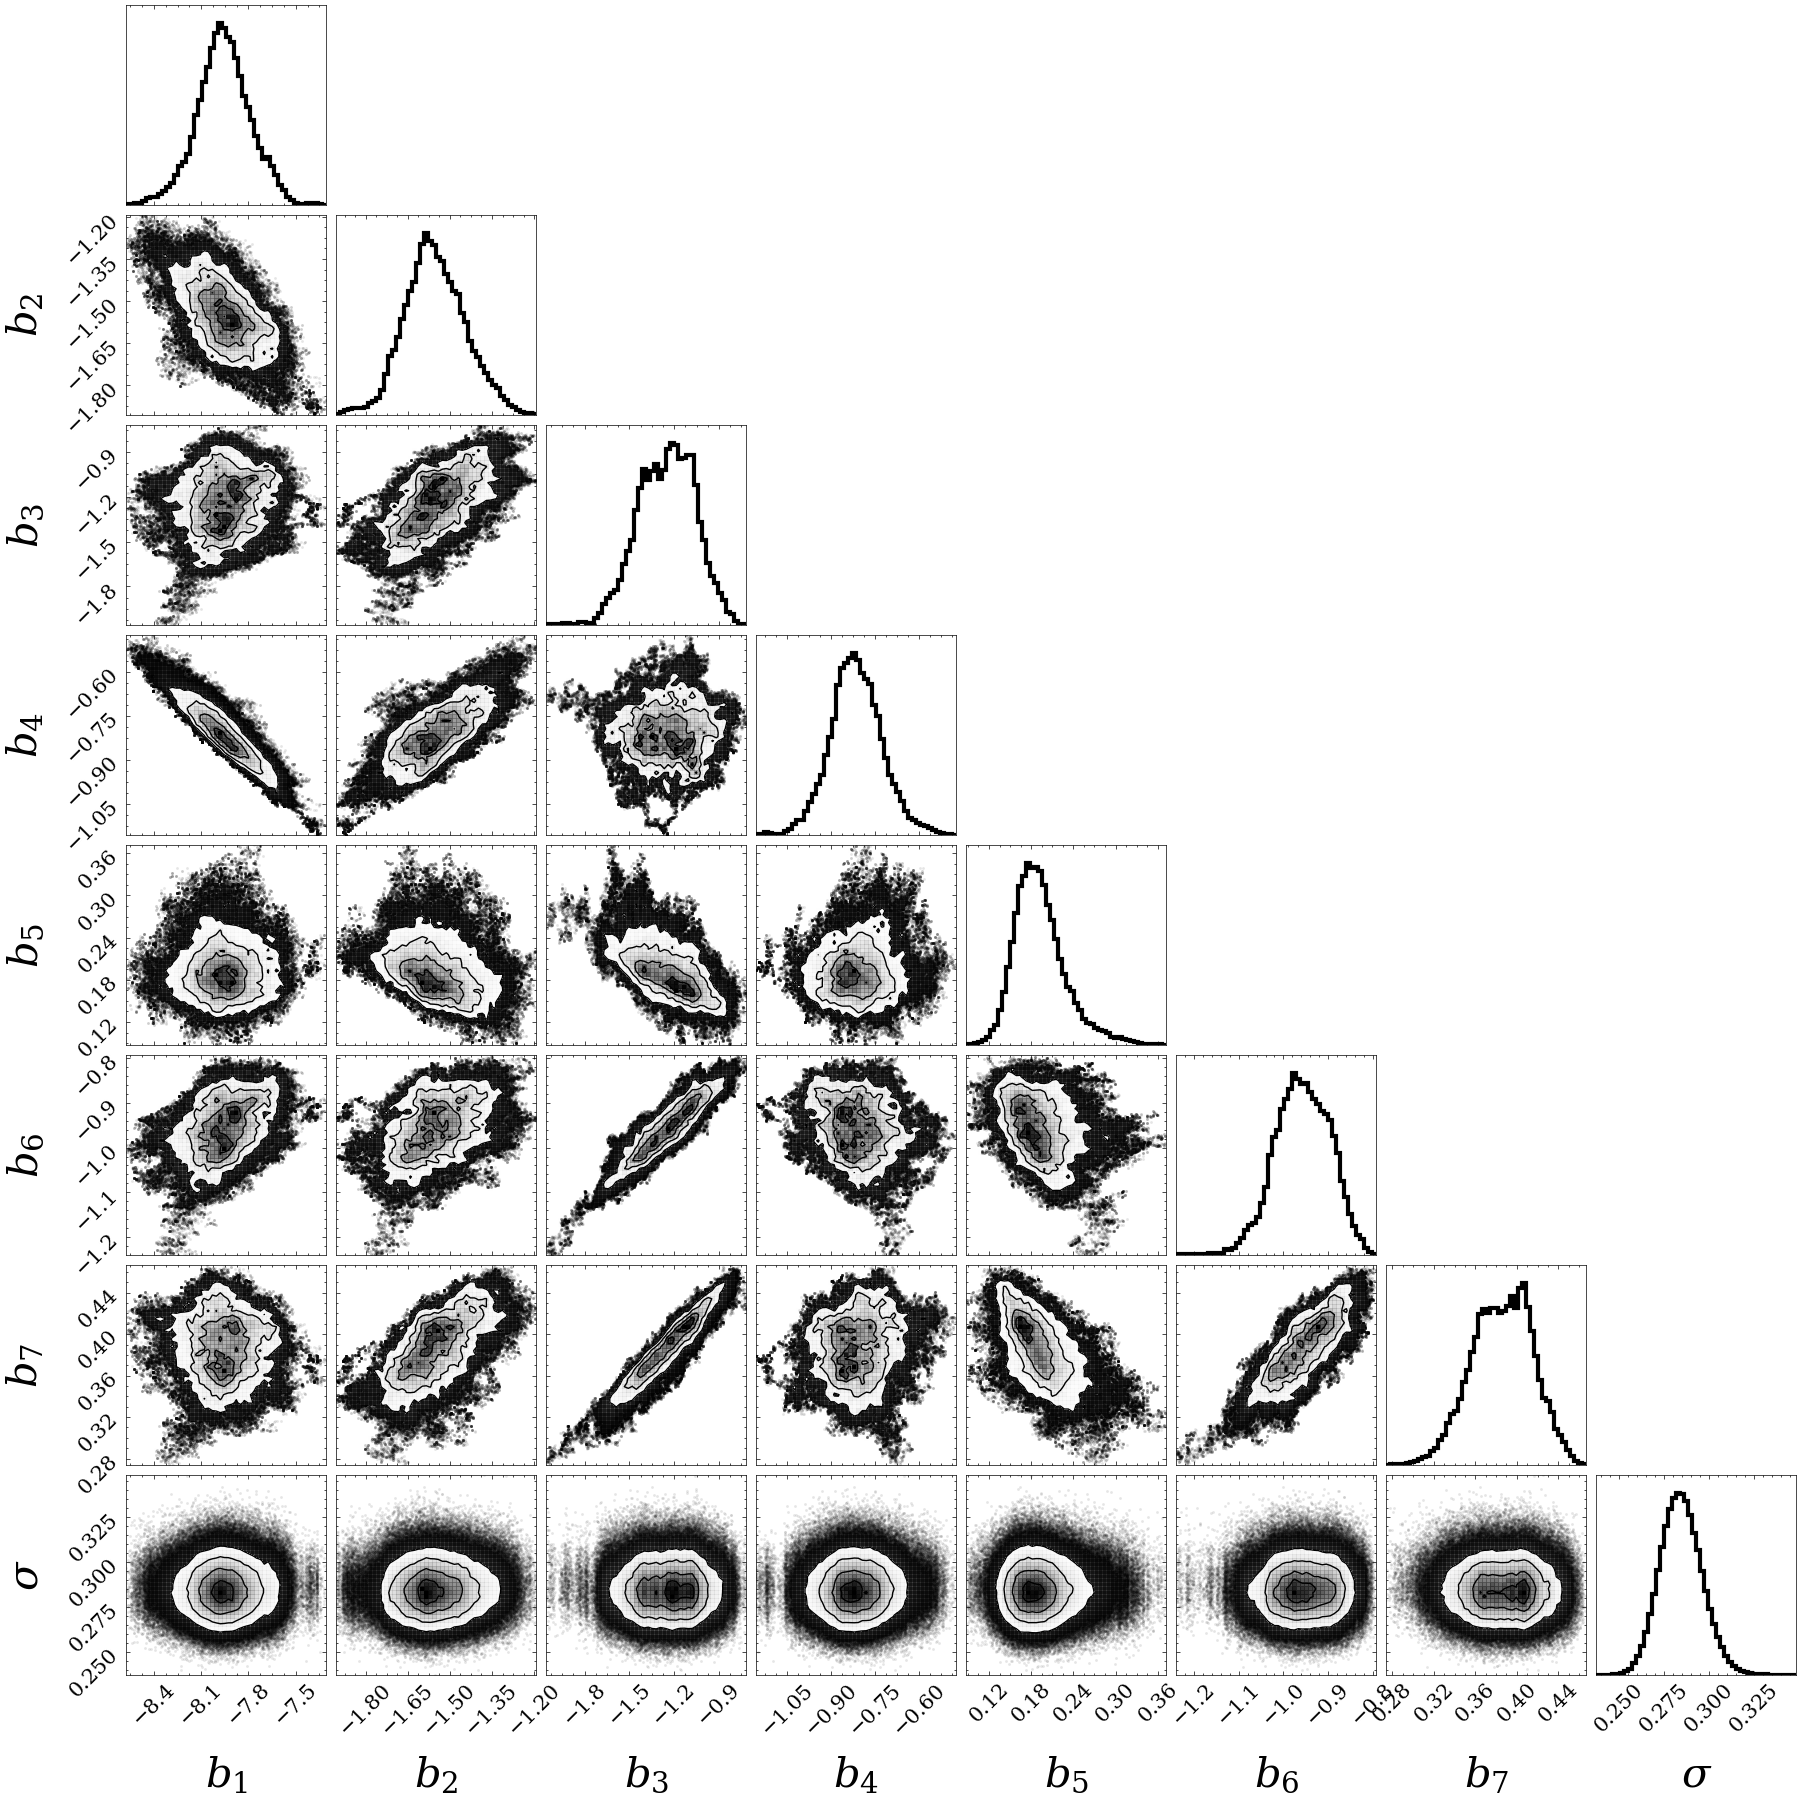

In [102]:
plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples_simplex_weighted,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_weighted, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [103]:
X_full_filtered_weighted

array([[ 8.17664504e+02,  8.42652479e+02,  8.66250910e+02,
         8.88725040e+02,  9.10159117e+02,  9.30680940e+02,
         9.50349153e+02,  9.69117446e+02,  9.86962943e+02,
         1.00389922e+03,  1.01995578e+03,  1.03515291e+03,
         1.04959637e+03,  1.06329948e+03,  1.07629198e+03,
         1.08853148e+03,  1.09949035e+03,  1.10416511e+03],
       [-3.87444344e+00, -4.85879025e+00, -5.48472853e+00,
        -5.97312743e+00, -6.46050065e+00, -6.90500438e+00,
        -7.08947258e+00, -7.05760523e+00, -6.79070452e+00,
        -6.13651732e+00, -5.48718209e+00, -4.52482184e+00,
        -3.54935296e+00, -2.36351944e+00, -1.23167729e+00,
         9.23772816e-02,  1.55826145e+00,  1.23909317e+00],
       [-1.53495905e+00, -3.10958683e+00, -3.60055640e+00,
        -3.23430192e+00, -2.08593781e+00, -8.76698566e-01,
         1.49817385e-01,  8.18946460e-01,  1.14716004e+00,
         1.12947857e+00,  8.89053273e-01,  4.16625434e-01,
        -2.32269582e-01, -7.86047049e-01, -1.58308942e

In [104]:
np.random.seed(142857)
# We will now try to see our predictions from the parameters obtained from the gibbs_sampling function

rng = np.random.default_rng()
# We now have a list that contains all the parameters sampled from our gibbs function. Let's try extract 100000 data points from that and
# calculate the predictions of our models based on these parameters
    
samples_random_simplex_weighted = rng.choice(samples_simplex_weighted, 200000, replace = False)

In [105]:
params_random_full_simplex_weighted = np.array([  np.insert(samples_random_simplex_weighted[i][:-1], 0, 1)  for i in range(len(samples_random_simplex_weighted))  ])

yvals_random_simplex_weighted = params_random_full_simplex_weighted.dot(X_full_filtered_weighted)

In [106]:
weight_filtered_list = weight_list[filtered_models_output.index]
weight_filtered_matrix = np.diag(weight_filtered_list)

In [107]:
scaled_yvals_random_simplex_weighted = yvals_random_simplex_weighted.dot(np.linalg.inv(weight_filtered_matrix))

In [108]:
scaled_yvals_random_simplex_weighted[0]

array([ 867.33126589,  901.56856468,  929.01205307,  952.05680889,
        972.99593345,  992.91432986, 1010.15603496, 1025.42682531,
       1038.86994962, 1049.12572047, 1059.03370236, 1066.71634376,
       1073.93345049, 1078.60106344, 1084.1746233 , 1086.86816213,
       1087.72437798, 1103.18371217])

In [109]:
rndm_m_simplex_weighted = np.array([yvals_random_simplex_weighted[i] + np.random.multivariate_normal( np.full(len(yvals_random_simplex_weighted[i]), 0),\
                        np.diag(np.full(len(yvals_random_simplex_weighted[i]), samples_random_simplex_weighted[i][-1]**2)) ) \
                        for i in range(len(yvals_random_simplex_weighted)) ])

In [110]:
rndm_m_simplex_weighted.shape

(200000, 18)

In [111]:
filtered_models_output

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,UNEDF2,FRDM12,HFB24,BCPM,D1M,AME2020
240,50,50,100,825.941,822.052,826.926,828.530,826.288242,822.691386,828.611583,824.726244,826.912170,828.830587,829.853181,825.52,824.885137,823.496576,822.968432,825.162600
241,52,50,102,848.659,846.196,849.814,851.207,849.364428,847.781508,851.605589,848.943443,851.417385,852.516320,853.344606,850.23,849.067773,846.791661,845.646524,849.091993
242,54,50,104,870.666,869.126,871.759,873.135,871.383529,871.023119,873.167295,871.236657,874.244098,874.546832,875.381538,872.84,872.200409,869.065886,867.415059,871.926786
243,56,50,106,891.969,891.217,893.213,894.343,892.190570,892.942648,893.767401,892.399488,895.584326,895.511521,896.210348,894.41,893.713045,890.480655,888.405181,893.796060
244,58,50,108,912.716,912.408,914.077,914.826,911.582569,913.579282,913.499580,912.620544,915.727306,915.682848,915.839110,914.78,914.315681,911.281193,908.688814,914.654948
245,60,50,110,932.674,932.575,934.246,934.568,930.135328,933.197027,932.670884,932.051589,935.014543,934.973849,934.785166,934.59,934.058316,931.323345,928.295250,934.569625
246,62,50,112,952.012,951.805,953.690,953.532,948.361300,952.039737,951.230248,950.784548,953.622055,953.510473,953.085434,953.49,953.000952,950.673809,947.226378,953.525317
247,64,50,114,970.364,970.102,972.308,971.678,966.282253,970.160814,969.054331,968.793607,971.551835,971.249964,970.970799,971.47,971.073588,969.321409,965.470068,971.572649
248,66,50,116,988.071,987.348,990.025,988.990,983.758860,987.617816,986.193294,986.150392,988.821770,988.311787,988.017985,988.60,988.436224,987.002771,983.022213,988.681526
249,68,50,118,1004.653,1003.724,1006.883,1005.503,1000.771672,1004.358485,1002.927549,1002.858717,1005.495934,1004.626641,1004.059960,1004.84,1005.008860,1004.373072,999.910286,1004.951024


In [112]:
scaled_rndm_m_simplex_weighted = rndm_m_simplex_weighted.dot(np.linalg.inv(np.sqrt(weight_filtered_matrix)))

In [113]:
lower_simplex_weighted = np.percentile(scaled_rndm_m_simplex_weighted, 2.5, axis = 0)
median_simplex_weighted = np.percentile(scaled_rndm_m_simplex_weighted, 50, axis = 0)
upper_simplex_weighted = np.percentile(scaled_rndm_m_simplex_weighted, 97.5, axis = 0)

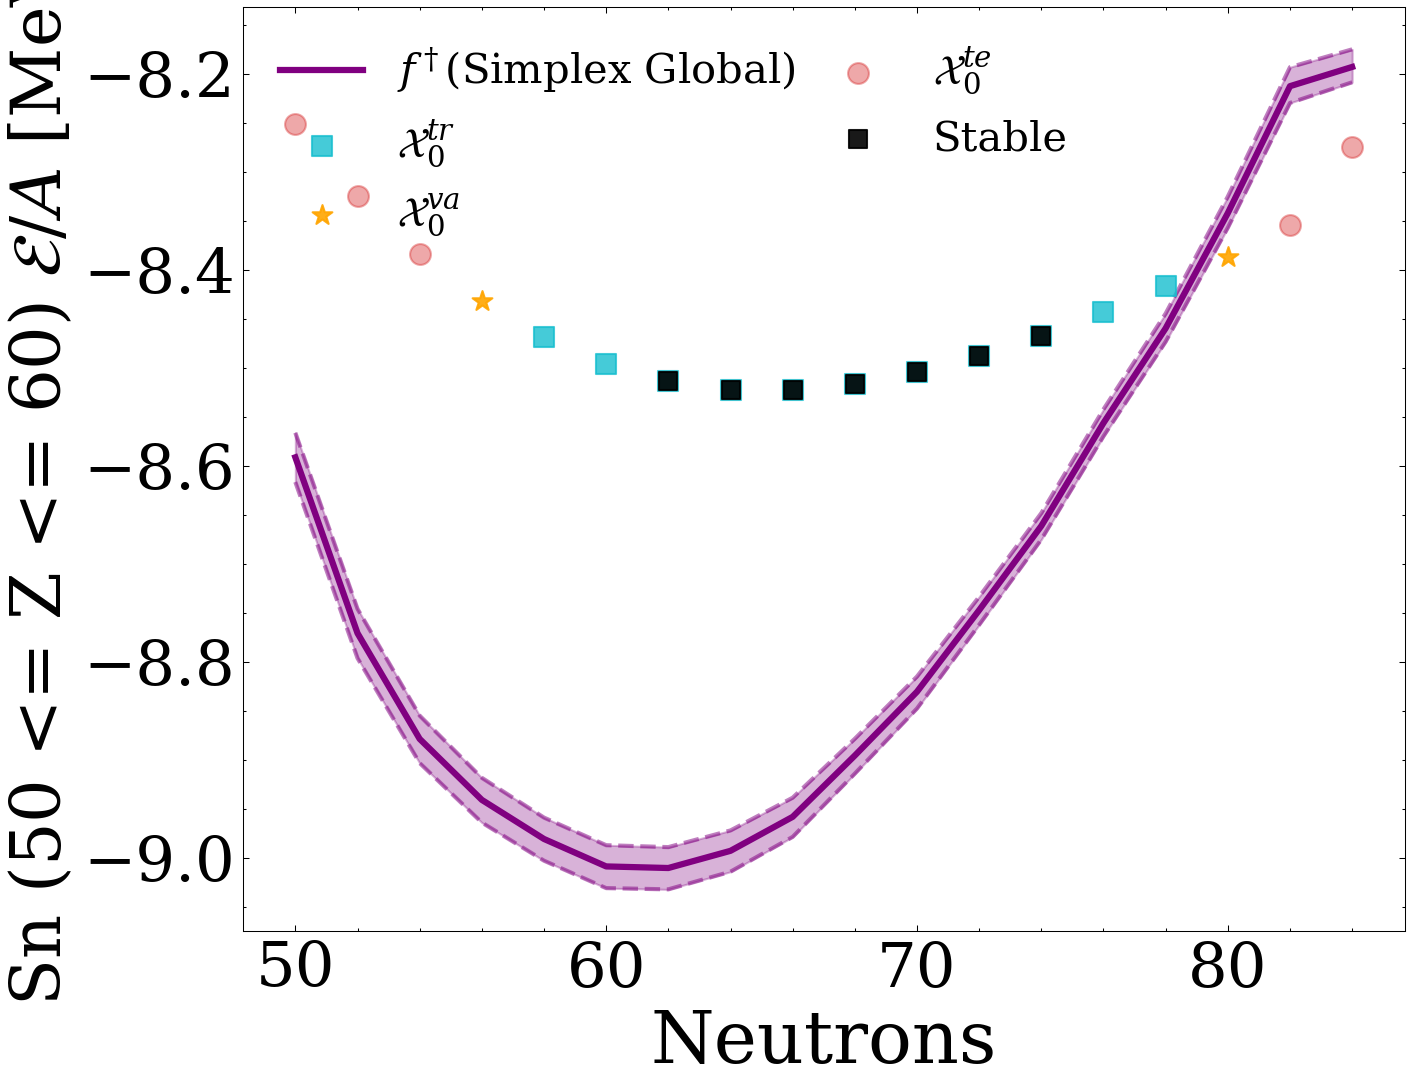

In [114]:
plt.rc("xtick", labelsize=30)
plt.rc("ytick", labelsize=30)

fig, ax = plt.subplots(figsize=(10,8), dpi=150)

plt.plot(filtered_models_output["N"], -median_simplex_weighted/filtered_models_output['A'], color="purple", label='$f^\dagger$(Simplex Global)',linewidth=3)

plt.plot(filtered_models_output["N"], -lower_simplex_weighted/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.5)
plt.plot(filtered_models_output["N"], -upper_simplex_weighted/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.5)

plt.fill_between(filtered_models_output["N"], -lower_simplex_weighted/filtered_models_output['A'], -upper_simplex_weighted/filtered_models_output['A'], color="purple",alpha=0.3)

color_local= "khaki"


# plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color=color_local, label='$f^\dagger$(Simplex Local)',linewidth=3)

# # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
# # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)


# plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.8)
# plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.8)

# plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color=color_local,alpha=0.3)

ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['AME2020']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_trainig,color=color_trainig,s=100,marker=marker_trainig,zorder=2)

ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['AME2020']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['AME2020']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_testing,color=color_testing,s=100,marker=marker_testing,zorder=2)

ax.scatter(x = filtered_models_output_stable["N"], y =- filtered_models_output_stable['AME2020']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)





plt.xlabel("Neutrons",fontsize=35)
plt.ylabel("Sn (50 <= Z <= 60) $ {\cal E}/A$ [MeV]",fontsize=33)
# plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
 
plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

# plt.savefig('Plots/Model Forecasts Comparison in Simplex Case.png')
plt.show()
